# Fake News Detection — Arabic NLP
**Pipeline complet :** nettoyage → TF-IDF → ML classiques → BiLSTM → XLM-RoBERTa

---
### Structure du notebook
| Étape | Description |
|-------|-------------|
| 1 | Installation & Configuration globale |
| 2 | Chargement & Exploration des données |
| 3 | Nettoyage & Préparation du texte arabe |
| 4 | Split train/test (unique, cohérent) |
| 5 | Vectorisation TF-IDF + Tokenisation Keras |
| 6 | Feature Engineering (Word2Vec, Doc2Vec, AraBERT) |
| 7 | Modèles ML classiques (LR, RF, XGBoost) |
| 8 | Modèle Deep Learning — BiLSTM |
| 9 | Fine-tuning XLM-RoBERTa |
| 10 | Comparaison finale des modèles |
| 11 | Inférence / Prédiction |

> ⚡ **Checkpoint automatique** : chaque étape coûteuse est sauvegardée sur Drive et rechargée si elle existe déjà. Exécuter dans l'ordre la première fois, puis reprendre librement depuis n'importe quelle étape.

## Étape 1 — Installation & Configuration globale
> Exécuter cette cellule **en premier**, puis **redémarrer le kernel** si c'est la toute première exécution.

In [ ]:
# ============================================================
# 1.1 — Installation des dépendances
# ============================================================
!pip install gensim xgboost transformers datasets -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 56.8 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 1.2 — Imports standards (UNIQUE cellule d'imports)
# ============================================================
import os, re, gc, pickle, warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from tqdm import tqdm
warnings.filterwarnings('ignore')

# NLP
import nltk
nltk.download('stopwords', quiet=True)
nltk.download('punkt',     quiet=True)
nltk.download('punkt_tab', quiet=True)
from nltk.tokenize import word_tokenize

# Machine Learning
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
from xgboost import XGBClassifier

# Embeddings
from gensim.models import Word2Vec, Doc2Vec
from gensim.models.doc2vec import TaggedDocument

# Deep Learning
import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import (
    Input, Embedding, Bidirectional, LSTM,
    Dropout, BatchNormalization, Dense, GlobalMaxPooling1D
)
from tensorflow.keras.preprocessing.text import Tokenizer as KerasTokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam

# Transformers
import torch
from transformers import (
    XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
    AutoTokenizer, AutoModel, Trainer, TrainingArguments
)
from datasets import Dataset

print(f'TensorFlow  : {tf.__version__}')
print(f'PyTorch     : {torch.__version__}')
print(f'GPU (TF)    : {tf.config.list_physical_devices("GPU")}')
print(f'GPU (Torch) : {"OUI" if torch.cuda.is_available() else "NON"}')

TensorFlow  : 2.19.0
PyTorch     : 2.10.0+cu128
GPU (TF)    : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]
GPU (Torch) : OUI


In [ ]:
# ============================================================
# 1.3 — Configuration globale : chemins, constantes, seed
# ============================================================
from google.colab import drive
drive.mount('/content/drive')

# ── Répertoires ────────────────────────────────────────────
BASE_DIR  = '/content/drive/MyDrive/FakeNewsArabic'
DATA_DIR  = BASE_DIR                              # CSV d'entrée
CKPT_DIR  = f'{BASE_DIR}/checkpoints'             # Objets intermédiaires
MODEL_DIR = f'{BASE_DIR}/models'                  # Modèles finaux
os.makedirs(CKPT_DIR,  exist_ok=True)
os.makedirs(MODEL_DIR, exist_ok=True)

# ── Constantes globales ────────────────────────────────────
SEED      = 42
TEST_SIZE = 0.20
MAX_WORDS = 50000   # Vocabulaire Keras (arabe morphologiquement riche)
MAX_LEN   = 300     # Longueur séquence LSTM

# ── Fichiers checkpoint (noms centralisés) ─────────────────
P = {
    'df_cleaned'   : f'{CKPT_DIR}/df_cleaned.pkl',
    'df_filtered'  : f'{CKPT_DIR}/df_filtered.pkl',
    'df_balanced'  : f'{CKPT_DIR}/df_balanced.pkl',
    'split'        : f'{CKPT_DIR}/split.pkl',
    'tfidf_vec'    : f'{CKPT_DIR}/tfidf_vectorizer.pkl',
    'tfidf_train'  : f'{CKPT_DIR}/X_train_tfidf.npz',
    'tfidf_test'   : f'{CKPT_DIR}/X_test_tfidf.npz',
    'tokens'       : f'{CKPT_DIR}/tokens.pkl',
    'keras_tok'    : f'{CKPT_DIR}/keras_tokenizer.pkl',
    'seq_train'    : f'{CKPT_DIR}/X_train_seq.npy',
    'seq_test'     : f'{CKPT_DIR}/X_test_seq.npy',
    'w2v_model'    : f'{CKPT_DIR}/word2vec.model',
    'w2v_train'    : f'{CKPT_DIR}/w2v_train.npy',
    'w2v_test'     : f'{CKPT_DIR}/w2v_test.npy',
    'd2v_model'    : f'{CKPT_DIR}/doc2vec.model',
    'd2v_train'    : f'{CKPT_DIR}/d2v_train.npy',
    'd2v_test'     : f'{CKPT_DIR}/d2v_test.npy',
    'arabert_train': f'{CKPT_DIR}/arabert_train.npy',
    'arabert_test' : f'{CKPT_DIR}/arabert_test.npy',
    'lstm_model'   : f'{CKPT_DIR}/lstm_model.keras',
    'lstm_history' : f'{CKPT_DIR}/lstm_history.pkl',
    'results'      : f'{CKPT_DIR}/all_results.pkl',
    'xlm_model'    : f'{MODEL_DIR}/xlm_roberta_finetuned',
}

np.random.seed(SEED)
tf.random.set_seed(SEED)

print('✅ Configuration chargée')
print(f'   CKPT_DIR  : {CKPT_DIR}')
print(f'   MODEL_DIR : {MODEL_DIR}')

Mounted at /content/drive
✅ Configuration chargée
   CKPT_DIR  : /content/drive/MyDrive/FakeNewsArabic/checkpoints
   MODEL_DIR : /content/drive/MyDrive/FakeNewsArabic/models


In [ ]:
# ============================================================
# 1.4 — Fonctions utilitaires communes
# ============================================================

def ckpt_save(path, obj, fmt='pickle'):
    """Sauvegarde intelligente selon le format."""
    if fmt == 'pickle':
        with open(path, 'wb') as f:
            pickle.dump(obj, f, protocol=4)
    elif fmt == 'joblib':
        joblib.dump(obj, path)
    elif fmt == 'npy':
        np.save(path, obj)
    elif fmt == 'npz':
        sp.save_npz(path, obj)
    print(f'  💾 Sauvegardé → {os.path.basename(path)}')


def ckpt_load(path, fmt='pickle'):
    """Chargement selon le format."""
    if fmt == 'pickle':
        with open(path, 'rb') as f:
            return pickle.load(f)
    elif fmt == 'joblib':
        return joblib.load(path)
    elif fmt == 'npy':
        return np.load(path, allow_pickle=False)
    elif fmt == 'npz':
        return sp.load_npz(path)


def ckpt_exists(*paths):
    """Retourne True si tous les chemins existent."""
    return all(os.path.exists(p) for p in paths)


def compute_metrics(y_true, y_pred, y_proba=None, model_name='Model'):
    """Calcule et affiche les métriques standard + retourne un dict."""
    metrics = {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred),  4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred,    zero_division=0), 4),
        'F1'       : round(f1_score(y_true, y_pred,        zero_division=0), 4),
    }
    if y_proba is not None:
        metrics['AUC'] = round(roc_auc_score(y_true, y_proba), 4)

    print(f'\n── {model_name} ──')
    for k, v in metrics.items():
        if k != 'Model':
            print(f'   {k:<10}: {v}')
    print(classification_report(y_true, y_pred,
          target_names=['Real (0)', 'Fake (1)'], zero_division=0))
    return metrics


def plot_confusion(y_true, y_pred, title='Matrice de Confusion'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'], ax=ax)
    ax.set_xlabel('Prédit'); ax.set_ylabel('Réel')
    ax.set_title(title)
    plt.tight_layout(); plt.show()


print('✅ Fonctions utilitaires définies')

✅ Fonctions utilitaires définies


---
## Étape 2 — Chargement & Exploration des données
> Chargement du dataset, normalisation des labels, vérifications.

In [ ]:
# ── Chargement ─────────────────────────────────────────────
CSV_PATH = f'{DATA_DIR}/final_data_100k.csv'  # ← adapter si nécessaire

df = pd.read_csv(CSV_PATH)
print(f'Shape brut   : {df.shape}')
print(f'Colonnes     : {df.columns.tolist()}')
print(f'NaN par col  :\n{df.isna().sum()}\n')

# ── Suppression des lignes critiques manquantes ────────────
df = df.dropna(subset=['text', 'label'])

# ── Normalisation du label (robuste aux formats string/int) ─
label_map = {
    'fake': 1, 'faux': 1, '1': 1, '1.0': 1,
    'real': 0, 'vrai': 0, 'true': 0, '0': 0, '0.0': 0
}
df['label'] = df['label'].astype(str).str.strip().str.lower().map(label_map)
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(np.int8)  # int8 économise ~4x la RAM vs int64

# ── Colonnes facultatives ──────────────────────────────────
if 'title' not in df.columns:
    df['title'] = ''
df = df.reset_index(drop=True)

print(f'Shape final  : {df.shape}')
print(f'Distribution :\n{df["label"].value_counts()}')
print(f'% par classe :\n{(df["label"].value_counts(normalize=True)*100).round(1)}')
df.head(3)

Shape brut   : (100000, 3)
Colonnes     : ['title', 'text', 'label']
NaN par col  :
title    1
text     0
label    0
dtype: int64

Shape final  : (100000, 3)
Distribution :
label
0    55687
1    44313
Name: count, dtype: int64
% par classe :
label
0    55.7
1    44.3
Name: proportion, dtype: float64


,title,text,label
0,إقفال جميع المصارف العاملة في لبنان غدا تضامنا...,قالت جمعية مصارف لبنان بيان الاثنين البنوك لبن...,1
1,وزارة الصحة تؤكد على ايجابيات اللقاح في خفض حد...,المستقلة أكدت وزارة الصحة إيجابيات اللقاح تكمن...,1
2,الرئيس الأميركي ورئيس الوزراء الإيرلندي يبحثان...,واشنطن 05 شعبان 1442 هـ الموافق 18 2021 واسبحث...,0


---
## Étape 3 — Nettoyage & Préparation du texte arabe
> Pipeline complet : URLs → diacritiques → normalisation → ponctuation → stopwords → chiffres.  
> **Checkpoint** : résultat sauvegardé dans `df_cleaned.pkl`, `df_filtered.pkl`, `df_balanced.pkl`.

In [ ]:
# ── Stopwords arabes ───────────────────────────────────────
ARABIC_SW = frozenset([
    'في', 'من', 'على', 'إلى', 'عن', 'مع', 'أن', 'أو', 'ليس', 'كان',
    'لم', 'أنها', 'هو', 'هي', 'أنت', 'هم', 'الذي', 'التي', 'هذا',
    'هذه', 'منها', 'كل', 'ماذا', 'أي', 'كيف', 'ذلك', 'لن', 'لذلك',
    'لكن', 'لقد', 'جميع', 'أثناء'
])

# ── Regex pré-compilées (gain perf sur 100k textes) ───────
_RE_URL        = re.compile(r'https?://\S+|www\.\S+')
_RE_DIACRITICS = re.compile(r'[\u064B-\u065F\u0670\u0640]')
_RE_DIGITS     = re.compile(r'\d+')
_RE_SPACES     = re.compile(r'\s+')
_RE_PUNCT      = re.compile(r'[\u060C\u061B\u061F\u0021-\u002F\u003A-\u0040'
                             r'\u005B-\u0060\u007B-\u007E\u00D7\u00F7\u2026\u2013\u2014]')

def clean_arabic_text(text: str) -> str:
    if not isinstance(text, str) or not text.strip():
        return ''
    text = _RE_URL.sub('', text)
    text = _RE_DIACRITICS.sub('', text)
    # Normalisation lettres arabes
    text = re.sub('[إأآا]', 'ا', text)
    text = re.sub('ى', 'ي', text)
    text = re.sub('[ؤئ]', 'و', text)  # ئ → و est discutable mais cohérent
    text = text.replace('ة', 'ه')
    text = _RE_PUNCT.sub(' ', text)
    text = ' '.join(w for w in text.split() if w not in ARABIC_SW)
    text = _RE_DIGITS.sub('', text)
    text = _RE_SPACES.sub(' ', text)
    return text.strip()

print('✅ Fonctions de nettoyage définies')

✅ Fonctions de nettoyage définies


In [ ]:
# ── ÉTAPE 3.1 — Nettoyage du texte ────────────────────────
if ckpt_exists(P['df_cleaned']):
    print('⏩ df_cleaned déjà fait — chargement...')
    df = ckpt_load(P['df_cleaned'])
else:
    print('🔄 Nettoyage du texte arabe...')
    tqdm.pandas(desc='title')
    df['title'] = df['title'].astype(str).progress_apply(clean_arabic_text)
    tqdm.pandas(desc='text')
    df['text']  = df['text'].astype(str).progress_apply(clean_arabic_text)
    df['text_len'] = df['text'].str.len()
    ckpt_save(P['df_cleaned'], df)

print(f'Shape : {df.shape}')
print(df.head(2))

🔄 Nettoyage du texte arabe...


text: 100%|██████████| 100000/100000 [00:27<00:00, 3574.47it/s]


  💾 Sauvegardé → df_cleaned.pkl
Shape : (100000, 4)
                                               title  \
0  اقفال المصارف العامله لبنان غدا تضامنا «اللبنا...   
1  وزاره الصحه توكد علي ايجابيات اللقاح خفض حده ا...   

                                                text  label  text_len  
0  قالت جمعيه مصارف لبنان بيان الاثنين البنوك لبن...      1       325  
1  المستقله اكدت وزاره الصحه ايجابيات اللقاح تكمن...      1       447  


In [ ]:
# ── ÉTAPE 3.2 — Filtrage par longueur ─────────────────────
if ckpt_exists(P['df_filtered']):
    print('⏩ df_filtered déjà fait — chargement...')
    df = ckpt_load(P['df_filtered'])
else:
    before = len(df)
    df = df[(df['text_len'] >= 15) & (df['text_len'] <= 5000)].reset_index(drop=True)
    print(f'Avant filtrage : {before:,} | Après : {len(df):,} | Supprimées : {before-len(df):,}')
    ckpt_save(P['df_filtered'], df)

# ── ÉTAPE 3.3 — Équilibrage des classes ───────────────────
if ckpt_exists(P['df_balanced']):
    print('⏩ df_balanced déjà fait — chargement...')
    df = ckpt_load(P['df_balanced'])
else:
    n = df['label'].value_counts().min()
    df = (
        df.groupby('label', group_keys=False)
          .apply(lambda g: g.sample(n, random_state=SEED))
          .sample(frac=1, random_state=SEED)
          .reset_index(drop=True)
    )
    print(f'Dataset équilibré : {df.shape}')
    print(df['label'].value_counts())
    ckpt_save(P['df_balanced'], df)

# ── Construction X (full text = title + text) ─────────────
df['full_text'] = (df['title'] + ' ' + df['text']).str.strip()
print(f'\nDistribution finale :\n{df["label"].value_counts()}')

Avant filtrage : 100,000 | Après : 98,700 | Supprimées : 1,300
  💾 Sauvegardé → df_filtered.pkl
Dataset équilibré : (87770, 4)
label
0    43885
1    43885
Name: count, dtype: int64
  💾 Sauvegardé → df_balanced.pkl

Distribution finale :
label
0    43885
1    43885
Name: count, dtype: int64


---
## Étape 4 — Split train/test (unique & cohérent)
> **Point critique** : un seul split est fait ici avec `SEED=42`. Toutes les étapes suivantes
> (TF-IDF, LSTM, embeddings) utilisent ce même split → alignement garanti des labels.

In [ ]:
if ckpt_exists(P['split']):
    print('⏩ Split déjà fait — chargement...')
    split = ckpt_load(P['split'])
else:
    X_all = df['full_text'].values
    y_all = df['label'].values

    X_train, X_test, y_train, y_test = train_test_split(
        X_all, y_all,
        test_size=TEST_SIZE, random_state=SEED, stratify=y_all
    )
    split = {
        'X_train': X_train, 'X_test': X_test,
        'y_train': y_train.astype(np.int32),
        'y_test' : y_test.astype(np.int32),
    }
    ckpt_save(P['split'], split)

X_train = split['X_train']
X_test  = split['X_test']
y_train = split['y_train']
y_test  = split['y_test']

print(f'Train : {len(X_train):,} | Test : {len(X_test):,}')
print(f'y_train dist : {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'y_test  dist : {dict(zip(*np.unique(y_test,  return_counts=True)))}')

# Libérer df si mémoire serrée (garder full_text pour XLM-RoBERTa)
# df = df[['full_text', 'label']].copy(); gc.collect()

  💾 Sauvegardé → split.pkl
Train : 70,216 | Test : 17,554
y_train dist : {np.int32(0): np.int64(35108), np.int32(1): np.int64(35108)}
y_test  dist : {np.int32(0): np.int64(8777), np.int32(1): np.int64(8777)}


---
## Étape 5 — Vectorisation TF-IDF + Tokenisation Keras
> **TF-IDF** : matrices sparse sauvegardées en `.npz` (format optimal).  
> **Keras Tokenizer** : séquences entières pour le LSTM, sauvegardées en `.npy`.

In [ ]:
# ── ÉTAPE 5.1 — TF-IDF ────────────────────────────────────
if ckpt_exists(P['tfidf_vec'], P['tfidf_train'], P['tfidf_test']):
    print('⏩ TF-IDF déjà fait — chargement...')
    vectorizer    = ckpt_load(P['tfidf_vec'])
    X_train_tfidf = ckpt_load(P['tfidf_train'], fmt='npz').astype(np.float32)
    X_test_tfidf  = ckpt_load(P['tfidf_test'],  fmt='npz').astype(np.float32)
else:
    print('🔄 Vectorisation TF-IDF...')
    vectorizer = TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=100_000,
        lowercase=True,
        stop_words=list(ARABIC_SW)
    )
    X_train_tfidf = vectorizer.fit_transform(X_train).astype(np.float32)
    X_test_tfidf  = vectorizer.transform(X_test).astype(np.float32)

    ckpt_save(P['tfidf_vec'],   vectorizer)
    ckpt_save(P['tfidf_train'], X_train_tfidf, fmt='npz')
    ckpt_save(P['tfidf_test'],  X_test_tfidf,  fmt='npz')

print(f'X_train_tfidf : {X_train_tfidf.shape}')
print(f'X_test_tfidf  : {X_test_tfidf.shape}')

🔄 Vectorisation TF-IDF...
  💾 Sauvegardé → tfidf_vectorizer.pkl
  💾 Sauvegardé → X_train_tfidf.npz
  💾 Sauvegardé → X_test_tfidf.npz
X_train_tfidf : (70216, 100000)
X_test_tfidf  : (17554, 100000)


In [ ]:
# ── ÉTAPE 5.2 — Tokenisation NLTK (pour Word2Vec / Doc2Vec) ─
if ckpt_exists(P['tokens']):
    print('⏩ Tokens NLTK déjà faits — chargement...')
    tok_data     = ckpt_load(P['tokens'])
    train_tokens = tok_data['train']
    test_tokens  = tok_data['test']
else:
    print('🔄 Tokenisation NLTK...')
    train_tokens = [word_tokenize(t) for t in tqdm(X_train, desc='Train')]
    test_tokens  = [word_tokenize(t) for t in tqdm(X_test,  desc='Test')]
    ckpt_save(P['tokens'], {'train': train_tokens, 'test': test_tokens})

print(f'Exemple : {train_tokens[0][:10]}')

# ── ÉTAPE 5.3 — Keras Tokenizer + Padding (pour LSTM) ─────
if ckpt_exists(P['keras_tok'], P['seq_train'], P['seq_test']):
    print('⏩ Séquences Keras déjà faites — chargement...')
    keras_tokenizer = ckpt_load(P['keras_tok'])
    X_train_seq     = ckpt_load(P['seq_train'], fmt='npy')
    X_test_seq      = ckpt_load(P['seq_test'],  fmt='npy')
else:
    print('🔄 Keras Tokenizer + Padding...')
    keras_tokenizer = KerasTokenizer(num_words=MAX_WORDS, oov_token='<OOV>')
    keras_tokenizer.fit_on_texts(X_train)  # fit sur TRAIN seulement

    X_train_seq = pad_sequences(
        keras_tokenizer.texts_to_sequences(X_train),
        maxlen=MAX_LEN, padding='post', truncating='post', dtype='int32'
    )
    X_test_seq = pad_sequences(
        keras_tokenizer.texts_to_sequences(X_test),
        maxlen=MAX_LEN, padding='post', truncating='post', dtype='int32'
    )
    ckpt_save(P['keras_tok'],  keras_tokenizer)
    ckpt_save(P['seq_train'],  X_train_seq, fmt='npy')
    ckpt_save(P['seq_test'],   X_test_seq,  fmt='npy')

print(f'X_train_seq : {X_train_seq.shape} dtype={X_train_seq.dtype}')
print(f'X_test_seq  : {X_test_seq.shape}')
print(f'Taux zeros  : {(X_train_seq == 0).mean():.1%}')

🔄 Tokenisation NLTK...


Test: 100%|██████████| 17554/17554 [00:12<00:00, 1456.52it/s]


  💾 Sauvegardé → tokens.pkl
Exemple : ['اركان', 'فواد', 'يدين', 'رامز', 'جلال', 'بسبب', 'واقعه', 'الحذاء', 'كتب', 'دينا']
🔄 Keras Tokenizer + Padding...
  💾 Sauvegardé → keras_tokenizer.pkl
  💾 Sauvegardé → X_train_seq.npy
  💾 Sauvegardé → X_test_seq.npy
X_train_seq : (70216, 300) dtype=int32
X_test_seq  : (17554, 300)
Taux zeros  : 49.5%


---
## Étape 6 — Feature Engineering (Word2Vec, Doc2Vec, AraBERT)
> Chaque embedding est calculé une seule fois et sauvegardé en `.npy` ou `.model`.

In [ ]:
# ── ÉTAPE 6.1 — Word2Vec ───────────────────────────────────
if ckpt_exists(P['w2v_train'], P['w2v_test']):
    print('⏩ Word2Vec déjà fait — chargement...')
    X_train_w2v = ckpt_load(P['w2v_train'], fmt='npy')
    X_test_w2v  = ckpt_load(P['w2v_test'],  fmt='npy')
else:
    print('🔄 Entraînement Word2Vec...')
    w2v = Word2Vec(
        sentences=train_tokens, vector_size=100,
        window=5, min_count=2, workers=4, epochs=20, seed=SEED
    )
    w2v.save(P['w2v_model'])

    def avg_w2v(tokens_list, wv, dim=100):
        out = np.zeros((len(tokens_list), dim), dtype=np.float32)
        for i, toks in enumerate(tokens_list):
            valid = [wv[w] for w in toks if w in wv]
            if valid:
                out[i] = np.mean(valid, axis=0)
        return out

    X_train_w2v = avg_w2v(train_tokens, w2v.wv)
    X_test_w2v  = avg_w2v(test_tokens,  w2v.wv)
    ckpt_save(P['w2v_train'], X_train_w2v, fmt='npy')
    ckpt_save(P['w2v_test'],  X_test_w2v,  fmt='npy')
    del w2v; gc.collect()

print(f'X_train_w2v : {X_train_w2v.shape}')

🔄 Entraînement Word2Vec...


KeyboardInterrupt: 

In [ ]:
# ── ÉTAPE 6.2 — Doc2Vec ────────────────────────────────────
if ckpt_exists(P['d2v_train'], P['d2v_test']):
    print('⏩ Doc2Vec déjà fait — chargement...')
    X_train_d2v = ckpt_load(P['d2v_train'], fmt='npy')
    X_test_d2v  = ckpt_load(P['d2v_test'],  fmt='npy')
else:
    print('🔄 Entraînement Doc2Vec...')
    tagged = [TaggedDocument(words=t, tags=[i]) for i, t in enumerate(train_tokens)]
    d2v = Doc2Vec(
        documents=tagged, vector_size=100,
        window=5, min_count=2, workers=4, epochs=20, seed=SEED
    )
    d2v.save(P['d2v_model'])

    X_train_d2v = np.array(d2v.dv.vectors, dtype=np.float32)  # vecteurs entraînés
    X_test_d2v  = np.array(
        [d2v.infer_vector(t, epochs=20) for t in tqdm(test_tokens, desc='Infer')],
        dtype=np.float32
    )
    ckpt_save(P['d2v_train'], X_train_d2v, fmt='npy')
    ckpt_save(P['d2v_test'],  X_test_d2v,  fmt='npy')
    del d2v; gc.collect()

print(f'X_train_d2v : {X_train_d2v.shape}')

In [ ]:
# ── ÉTAPE 6.3 — AraBERT (aubmindlab/bert-base-arabertv2) ───
# ⚠️  Sur T4 Colab avec GPU : ~4-6 min. Sans GPU : plusieurs heures.
# Ce bloc force l'utilisation du GPU et optimise la mémoire avant de charger le modèle.

if ckpt_exists(P['arabert_train'], P['arabert_test']):
    print('⏩ AraBERT déjà fait — chargement...')
    X_train_arabert = ckpt_load(P['arabert_train'], fmt='npy')
    X_test_arabert  = ckpt_load(P['arabert_test'],  fmt='npy')
else:
    # ── DIAGNOSTIC GPU avant de commencer ──────────────────
    print('─'*55)
    print(f'CUDA disponible   : {torch.cuda.is_available()}')
    if torch.cuda.is_available():
        print(f'GPU               : {torch.cuda.get_device_name(0)}')
        mem_total = torch.cuda.get_device_properties(0).total_memory / 1e9
        mem_free  = (torch.cuda.get_device_properties(0).total_memory
                     - torch.cuda.memory_allocated(0)) / 1e9
        print(f'VRAM totale       : {mem_total:.1f} GB')
        print(f'VRAM libre        : {mem_free:.1f} GB')
    else:
        print('⚠️  PAS DE GPU DÉTECTÉ — AraBERT sera très lent sur CPU.')
        print('   → Runtime > Modifier le type de runtime > GPU T4')
    print('─'*55)

    # ── Forcer la libération GPU avant de charger BERT ──────
    # TensorFlow peut monopoliser le GPU → on limite sa réservation
    for gpu in tf.config.list_physical_devices('GPU'):
        tf.config.experimental.set_memory_growth(gpu, True)
    torch.cuda.empty_cache()
    gc.collect()

    # ── Force CUDA même si torch.cuda n'est pas détecté ─────
    # (arrive quand TF a déjà pris le GPU en session exclusive)
    if not torch.cuda.is_available():
        raise RuntimeError(
            'GPU non disponible pour PyTorch.\n'
            'Solutions :\n'
            '  1. Runtime > Modifier le type de runtime > GPU T4\n'
            '  2. Ou passer directement à LR+AraBERT en sautant cette étape'
        )

    device = torch.device('cuda')
    print(f'🔄 Encodage AraBERT sur {device}...')

    ARABERT_NAME  = 'aubmindlab/bert-base-arabertv2'
    _ab_tokenizer = AutoTokenizer.from_pretrained(ARABERT_NAME)
    _ab_model     = AutoModel.from_pretrained(ARABERT_NAME)
    _ab_model     = _ab_model.to(device).eval()

    # Vérification que le modèle est bien sur GPU
    param_device = next(_ab_model.parameters()).device
    print(f'  Modèle sur      : {param_device}')
    assert str(param_device) != 'cpu', 'ERREUR : modèle toujours sur CPU !'

    # ── Calibration automatique du batch_size ───────────────
    # T4 (15GB) → batch=64 | Autre GPU ≥8GB → batch=32 | <8GB → batch=16
    vram_gb    = torch.cuda.get_device_properties(0).total_memory / 1e9
    batch_size = 64 if vram_gb >= 14 else (32 if vram_gb >= 8 else 16)
    print(f'  VRAM            : {vram_gb:.1f} GB → batch_size = {batch_size}')

    def encode_arabert(texts, desc='Encoding'):
        """Encode les textes avec AraBERT (CLS token). Gestion mémoire GPU."""
        all_emb = []
        texts   = list(texts)  # évite les copies pandas
        for i in tqdm(range(0, len(texts), batch_size), desc=f'  {desc}'):
            batch = texts[i:i + batch_size]
            # max_length=64 : couvre ~90% des textes arabes courts/moyens
            # Augmenter à 128 si les textes sont longs (mais 2x plus lent)
            enc = _ab_tokenizer(
                batch,
                padding=True,
                truncation=True,
                max_length=64,
                return_tensors='pt'
            )
            enc = {k: v.to(device) for k, v in enc.items()}
            with torch.no_grad():
                out = _ab_model(**enc)
            # CLS token = vecteur représentatif du document
            cls = out.last_hidden_state[:, 0, :].cpu().numpy()
            all_emb.append(cls)
            # Vider le cache GPU toutes les 500 itérations
            if (i // batch_size) % 500 == 0:
                torch.cuda.empty_cache()
        return np.vstack(all_emb).astype(np.float32)

    X_train_arabert = encode_arabert(X_train, desc='Train')
    X_test_arabert  = encode_arabert(X_test,  desc='Test')

    ckpt_save(P['arabert_train'], X_train_arabert, fmt='npy')
    ckpt_save(P['arabert_test'],  X_test_arabert,  fmt='npy')

    # Libérer le GPU pour les étapes suivantes
    del _ab_model, _ab_tokenizer
    torch.cuda.empty_cache()
    gc.collect()
    print(f'  VRAM libérée : {torch.cuda.memory_allocated(0)/1e6:.0f} MB restants')

print(f'X_train_arabert : {X_train_arabert.shape}')
print(f'X_test_arabert  : {X_test_arabert.shape}')

───────────────────────────────────────────────────────
CUDA disponible   : True
GPU               : Tesla T4
VRAM totale       : 15.6 GB
VRAM libre        : 15.6 GB
───────────────────────────────────────────────────────
🔄 Encodage AraBERT sur cuda...


config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/611 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

...

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: aubmindlab/bert-base-arabertv2
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
bert.embeddings.position_ids               | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  Modèle sur      : cuda:0
  VRAM            : 15.6 GB → batch_size = 64


  Test: 100%|██████████| 275/275 [01:09<00:00,  3.98it/s]


  💾 Sauvegardé → arabert_train.npy
  💾 Sauvegardé → arabert_test.npy
  VRAM libérée : 10 MB restants
X_train_arabert : (70216, 768)
X_test_arabert  : (17554, 768)


---
## Étape 7 — Modèles ML classiques (LR, RF, XGBoost)
> Chaque modèle est entraîné avec GridSearchCV, sauvegardé en `.joblib`,  
> et ses métriques ajoutées à la liste `all_results`.
> Si un modèle existe déjà sur disque, il est chargé sans ré-entraînement.

In [ ]:
# ── Chargement des résultats déjà calculés ─────────────────
all_results = ckpt_load(P['results']) if ckpt_exists(P['results']) else []
trained_models = {r['Model'] for r in all_results}
print(f'Modèles déjà évalués : {trained_models or "aucun"}')

Modèles déjà évalués : aucun


In [ ]:
# ── Fonction générique d'entraînement + évaluation ─────────
def train_ml_model(name, model, X_tr, y_tr, X_te, y_te,
                   param_grid, model_path, cv=3, n_jobs=-1):
    """Entraîne, évalue, sauvegarde un modèle ML. Skip si déjà fait."""
    if ckpt_exists(model_path):
        print(f'⏩ {name} déjà entraîné — chargement...')
        best = ckpt_load(model_path, fmt='joblib')
    else:
        print(f'🔄 GridSearchCV {name}...')
        gc.collect()
        t0   = time()
        grid = GridSearchCV(
            model, param_grid, cv=cv,
            scoring='f1', n_jobs=n_jobs, verbose=0
        )
        grid.fit(X_tr, y_tr)
        best = grid.best_estimator_
        print(f'  Terminé en {time()-t0:.0f}s | Params : {grid.best_params_}')
        ckpt_save(model_path, best, fmt='joblib')

    y_pred = best.predict(X_te)
    y_proba = best.predict_proba(X_te)[:, 1] if hasattr(best, 'predict_proba') else None
    metrics = compute_metrics(y_te, y_pred, y_proba, name)
    plot_confusion(y_te, y_pred, title=f'Confusion Matrix — {name}')
    return best, metrics

In [ ]:
# ── 7.1 — Logistic Regression (TF-IDF) ────────────────────
MODEL_NAME = 'Logistic Regression'
if MODEL_NAME not in trained_models:
    lr_model, metrics = train_ml_model(
        MODEL_NAME,
        LogisticRegression(max_iter=500),
        X_train_tfidf, y_train,
        X_test_tfidf,  y_test,
        param_grid={'C': [0.1, 1.0, 10], 'solver': ['lbfgs'], 'penalty': ['l2']},
        model_path=f'{MODEL_DIR}/lr_model.joblib'
    )
    all_results.append(metrics)
    ckpt_save(P['results'], all_results)

In [ ]:
# ── 7.2 — Random Forest (TF-IDF) ──────────────────────────
MODEL_NAME = 'Random Forest'
if MODEL_NAME not in trained_models:
    rf_model, metrics = train_ml_model(
        MODEL_NAME,
        RandomForestClassifier(random_state=SEED, n_jobs=-1),
        X_train_tfidf, y_train,
        X_test_tfidf,  y_test,
        param_grid={'n_estimators': [100, 150], 'max_depth': [10, 20], 'max_features': ['sqrt']},
        model_path=f'{MODEL_DIR}/rf_model.joblib'
    )
    all_results.append(metrics)
    ckpt_save(P['results'], all_results)

In [ ]:
# ── 7.3 — XGBoost (TF-IDF) ────────────────────────────────
MODEL_NAME = 'XGBoost'
if MODEL_NAME not in trained_models:
    xgb_model, metrics = train_ml_model(
        MODEL_NAME,
        XGBClassifier(eval_metric='logloss', random_state=SEED, n_jobs=1, tree_method='hist'),
        X_train_tfidf, y_train,
        X_test_tfidf,  y_test,
        param_grid={
            'n_estimators': [50, 100],
            'max_depth':    [4, 6],
            'learning_rate': [0.1, 0.05],
            'subsample':    [0.8]
        },
        model_path=f'{MODEL_DIR}/xgb_model.joblib'
    )
    all_results.append(metrics)
    ckpt_save(P['results'], all_results)

# Libérer les matrices TF-IDF (lourdes) si plus nécessaires
del X_train_tfidf, X_test_tfidf; gc.collect()
print('✅ Matrices TF-IDF libérées')

In [ ]:
# ── 7.4 — LR sur Word2Vec ──────────────────────────────────
MODEL_NAME = 'LR + Word2Vec'
if MODEL_NAME not in trained_models:
    model_w2v, metrics = train_ml_model(
        MODEL_NAME,
        LogisticRegression(max_iter=500),
        X_train_w2v, y_train,
        X_test_w2v,  y_test,
        param_grid={'C': [0.1, 1.0, 10]},
        model_path=f'{MODEL_DIR}/lr_w2v.joblib'
    )
    all_results.append(metrics)
    ckpt_save(P['results'], all_results)

# ── 7.5 — LR sur Doc2Vec ───────────────────────────────────
MODEL_NAME = 'LR + Doc2Vec'
if MODEL_NAME not in trained_models:
    model_d2v, metrics = train_ml_model(
        MODEL_NAME,
        LogisticRegression(max_iter=500),
        X_train_d2v, y_train,
        X_test_d2v,  y_test,
        param_grid={'C': [0.1, 1.0, 10]},
        model_path=f'{MODEL_DIR}/lr_d2v.joblib'
    )
    all_results.append(metrics)
    ckpt_save(P['results'], all_results)



# Libérer embeddings denses
del X_train_w2v, X_test_w2v, X_train_d2v, X_test_d2v
d

🔄 GridSearchCV LR + AraBERT...
  Terminé en 180s | Params : {'C': 0.1}
  💾 Sauvegardé → lr_arabert.joblib

── LR + AraBERT ──
   Accuracy  : 0.682
   Precision : 0.683
   Recall    : 0.6794
   F1        : 0.6812
   AUC       : 0.766
              precision    recall  f1-score   support

    Real (0)       0.68      0.68      0.68      8777
    Fake (1)       0.68      0.68      0.68      8777

    accuracy                           0.68     17554
   macro avg       0.68      0.68      0.68     17554
weighted avg       0.68      0.68      0.68     17554



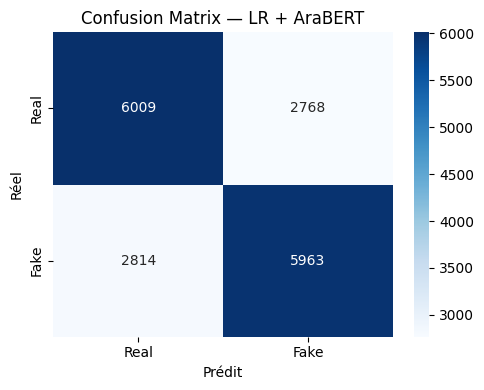

  💾 Sauvegardé → all_results.pkl
✅ Embeddings libérés


In [ ]:
# ── 7.6 — LR sur AraBERT ───────────────────────────────────
MODEL_NAME = 'LR + AraBERT'
if MODEL_NAME not in trained_models:
    model_ab, metrics = train_ml_model(
        MODEL_NAME,
        LogisticRegression(max_iter=500),
        X_train_arabert, y_train,
        X_test_arabert,  y_test,
        param_grid={'C': [0.1, 1.0, 10]},
        model_path=f'{MODEL_DIR}/lr_arabert.joblib'
    )
    all_results.append(metrics)
    ckpt_save(P['results'], all_results)

del X_train_arabert, X_test_arabert
gc.collect()
print('✅ Embeddings libérés')

---
## Étape 8 — Modèle Deep Learning — BiLSTM
> Architecture : `Input → Embedding → BiLSTM(128) → BiLSTM(64) → GlobalMaxPool → Dense`.  
> Sauvegardé au format `.keras` (recommandé TF ≥2.12). Rechargé automatiquement si existant.

In [ ]:
# ── Restauration des séquences si kernel relancé ───────────
if 'X_train_seq' not in dir() or X_train_seq is None:
    print('🔄 Rechargement séquences...')
    keras_tokenizer = ckpt_load(P['keras_tok'])
    X_train_seq     = ckpt_load(P['seq_train'], fmt='npy')
    X_test_seq      = ckpt_load(P['seq_test'],  fmt='npy')
    split           = ckpt_load(P['split'])
    y_train         = split['y_train']
    y_test          = split['y_test']
    print(f'  X_train_seq : {X_train_seq.shape} | y_train : {y_train.shape}')

# ── Split interne train/validation (10% du train) ──────────
X_tr_lstm, X_val_lstm, y_tr_lstm, y_val_lstm = train_test_split(
    X_train_seq, y_train,
    test_size=0.1, random_state=SEED, stratify=y_train
)
y_test_seq = y_test.astype(np.int32)
print(f'Train LSTM : {X_tr_lstm.shape} | Val : {X_val_lstm.shape}')

Train LSTM : (63194, 300) | Val : (7022, 300)


In [ ]:
# ── Construction du modèle amélioré ────────────────────────
def build_lstm(max_words, max_len, embed_dim=64):
    tf.keras.backend.clear_session()

    inputs = Input(shape=(max_len,), dtype='int32')

    x = Embedding(
        input_dim=max_words,
        output_dim=embed_dim,
        name='embedding',
        trainable=True
    )(inputs)

    # Meilleur que Dropout classique juste après Embedding
    x = SpatialDropout1D(0.25)(x)

    # 1er BiLSTM
    x = Bidirectional(
        LSTM(
            64,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(1e-4)
        ),
        name='bilstm_1'
    )(x)

    # 2e BiLSTM
    x = Bidirectional(
        LSTM(
            32,
            return_sequences=True,
            dropout=0.2,
            recurrent_dropout=0.2,
            kernel_regularizer=l2(1e-4)
        ),
        name='bilstm_2'
    )(x)

    # Pooling
    x = GlobalMaxPooling1D(name='global_max_pool')(x)

    # Dense block
    x = Dense(64, activation='relu', kernel_regularizer=l2(1e-4), name='dense_1')(x)
    x = Dropout(0.35, name='dropout_dense_1')(x)

    x = Dense(32, activation='relu', kernel_regularizer=l2(1e-4), name='dense_2')(x)
    x = Dropout(0.25, name='dropout_dense_2')(x)

    outputs = Dense(1, activation='sigmoid', name='output')(x)

    model = Model(inputs, outputs, name='bilstm_arabic_improved')

    model.compile(
        optimizer=Adam(learning_rate=5e-4),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.Precision(name='precision'),
            tf.keras.metrics.Recall(name='recall'),
            tf.keras.metrics.AUC(name='auc')
        ]
    )

    return model


# ── Entraînement ou chargement ─────────────────────────────
if ckpt_exists(P['lstm_model']):
    print('⏩ LSTM déjà entraîné — chargement...')
    lstm_model = tf.keras.models.load_model(P['lstm_model'])

else:
    print('🔄 Entraînement BiLSTM amélioré...')
    lstm_model = build_lstm(MAX_WORDS, MAX_LEN)
    lstm_model.summary()

    callbacks = [
        ModelCheckpoint(
            filepath=P['lstm_model'],
            monitor='val_loss',
            save_best_only=True,
            save_weights_only=False,
            mode='min',
            verbose=1
        ),
        ReduceLROnPlateau(
            monitor='val_loss',
            factor=0.5,
            patience=2,
            min_lr=1e-6,
            mode='min',
            verbose=1
        ),
        EarlyStopping(
            monitor='val_loss',
            patience=4,
            restore_best_weights=True,
            mode='min',
            verbose=1
        )
    ]

    history = lstm_model.fit(
        X_tr_lstm, y_tr_lstm,
        validation_data=(X_val_lstm, y_val_lstm),
        epochs=20,
        batch_size=64,
        verbose=1,
        callbacks=callbacks
    )

    # sauvegarde history
    with open(P['lstm_history'], 'wb') as f:
        pickle.dump(history.history, f)

    print(f'✅ LSTM sauvegardé → {P["lstm_model"]}')

⏩ LSTM déjà entraîné — chargement...


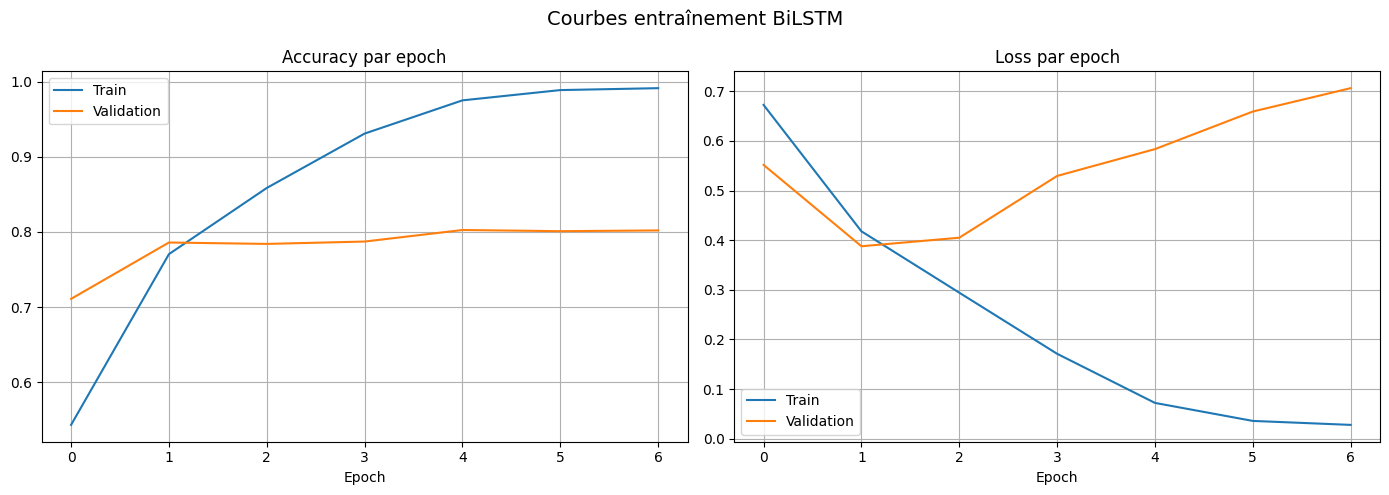

In [ ]:
# ── Courbes d'entraînement ─────────────────────────────────
if ckpt_exists(P['lstm_history']):
    with open(P['lstm_history'], 'rb') as f:
        hist = pickle.load(f)

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    for ax, metric, val_metric, title in [
        (axes[0], 'accuracy', 'val_accuracy', 'Accuracy'),
        (axes[1], 'loss',     'val_loss',     'Loss')
    ]:
        ax.plot(hist[metric],     label='Train')
        ax.plot(hist[val_metric], label='Validation')
        ax.set_title(f'{title} par epoch')
        ax.set_xlabel('Epoch'); ax.legend(); ax.grid(True)

    plt.suptitle('Courbes entraînement BiLSTM', fontsize=14)
    plt.tight_layout(); plt.show()
else:
    print('ℹ️  History non disponible (modèle chargé depuis disque)')

🔄 Prédiction sur test set...
275/275 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step

→ Seuil optimal : 0.5 | F1 : 0.8116

── BiLSTM ──
   Accuracy  : 0.7834
   Precision : 0.718
   Recall    : 0.9332
   F1        : 0.8116
   AUC       : 0.9065
              precision    recall  f1-score   support

    Real (0)       0.90      0.63      0.75      8777
    Fake (1)       0.72      0.93      0.81      8777

    accuracy                           0.78     17554
   macro avg       0.81      0.78      0.78     17554
weighted avg       0.81      0.78      0.78     17554



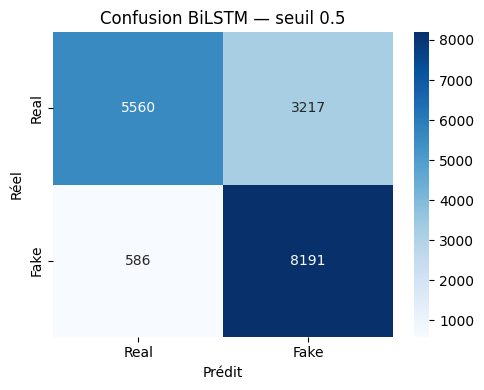

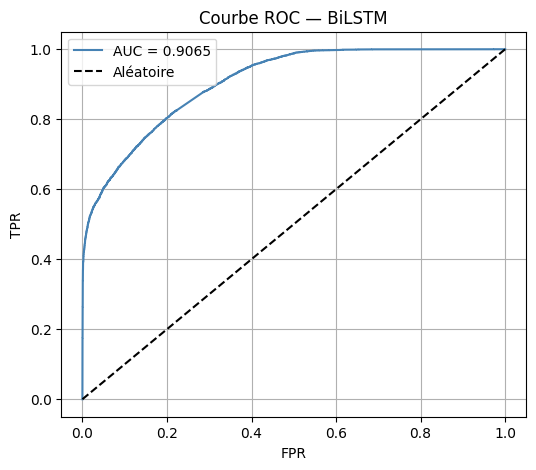

  💾 Sauvegardé → all_results.pkl


0

In [ ]:
# ── Évaluation LSTM ────────────────────────────────────────
print('🔄 Prédiction sur test set...')
y_proba_lstm = lstm_model.predict(
    X_test_seq.astype('int32'), batch_size=64, verbose=1
).flatten()

# ── Optimisation du seuil de décision ─────────────────────
thresholds   = np.arange(0.30, 0.76, 0.05)
thresh_res   = []
for t in thresholds:
    yp = (y_proba_lstm >= t).astype(int)
    thresh_res.append({'t': round(t, 2),
                       'f1': f1_score(y_test_seq, yp, zero_division=0)})

best = max(thresh_res, key=lambda x: x['f1'])
best_threshold = best['t']
print(f'\n→ Seuil optimal : {best_threshold} | F1 : {best["f1"]:.4f}')

y_pred_lstm = (y_proba_lstm >= best_threshold).astype(int)
metrics_lstm = compute_metrics(y_test_seq, y_pred_lstm, y_proba_lstm, 'BiLSTM')
plot_confusion(y_test_seq, y_pred_lstm, f'Confusion BiLSTM — seuil {best_threshold}')

# ── Courbe ROC ─────────────────────────────────────────────
fpr, tpr, _ = roc_curve(y_test_seq, y_proba_lstm)
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'AUC = {metrics_lstm["AUC"]:.4f}', color='steelblue')
plt.plot([0,1],[0,1], 'k--', label='Aléatoire')
plt.xlabel('FPR'); plt.ylabel('TPR')
plt.title('Courbe ROC — BiLSTM'); plt.legend(); plt.grid(True); plt.show()

# ── Ajout aux résultats ────────────────────────────────────
MODEL_NAME = 'BiLSTM'
if MODEL_NAME not in {r['Model'] for r in all_results}:
    all_results.append(metrics_lstm)
    ckpt_save(P['results'], all_results)

# Libérer GPU
del X_train_seq, X_test_seq
tf.keras.backend.clear_session(); gc.collect()

---
## Étape 9 — Fine-tuning XLM-RoBERTa
> Split 80/10/10 → tokenisation HuggingFace → Trainer → évaluation → sauvegarde.  
> **Nécessite GPU (T4 minimum)**. W&B désactivé par défaut.
>
> ⚠️ **Si le kernel a été relancé**, exécuter d'abord la cellule `9.0 — RESTORE` ci-dessous.

In [ ]:
# ============================================================
# 9.0 — RESTORE COMPLET après redémarrage du kernel
# Exécuter cette cellule EN PREMIER si le kernel a été relancé.
# Elle recharge toutes les variables nécessaires depuis Drive.
# ============================================================

# ── 1. Réimports si nécessaires ────────────────────────────
import os, re, gc, pickle, warnings
import numpy as np
import pandas as pd
import scipy.sparse as sp
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from time import time
from tqdm import tqdm
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_auc_score, roc_curve
)
import torch
from transformers import (
    XLMRobertaTokenizer, XLMRobertaForSequenceClassification,
    Trainer, TrainingArguments
)
from datasets import Dataset
import tensorflow as tf
warnings.filterwarnings('ignore')
os.environ['WANDB_DISABLED'] = 'true'

# ── 2. Remonter Drive ──────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive', force_remount=False)

# ── 3. Reconfigurer les chemins ────────────────────────────
BASE_DIR  = '/content/drive/MyDrive/FakeNewsArabic'
CKPT_DIR  = f'{BASE_DIR}/checkpoints'
MODEL_DIR = f'{BASE_DIR}/models'
SEED      = 42
MAX_WORDS = 50000
MAX_LEN   = 300
P = {
    'df_balanced'  : f'{CKPT_DIR}/df_balanced.pkl',
    'split'        : f'{CKPT_DIR}/split.pkl',
    'tfidf_vec'    : f'{CKPT_DIR}/tfidf_vectorizer.pkl',
    'tfidf_train'  : f'{CKPT_DIR}/X_train_tfidf.npz',
    'tfidf_test'   : f'{CKPT_DIR}/X_test_tfidf.npz',
    'keras_tok'    : f'{CKPT_DIR}/keras_tokenizer.pkl',
    'seq_train'    : f'{CKPT_DIR}/X_train_seq.npy',
    'seq_test'     : f'{CKPT_DIR}/X_test_seq.npy',
    'w2v_train'    : f'{CKPT_DIR}/w2v_train.npy',
    'w2v_test'     : f'{CKPT_DIR}/w2v_test.npy',
    'd2v_train'    : f'{CKPT_DIR}/d2v_train.npy',
    'd2v_test'     : f'{CKPT_DIR}/d2v_test.npy',
    'arabert_train': f'{CKPT_DIR}/arabert_train.npy',
    'arabert_test' : f'{CKPT_DIR}/arabert_test.npy',
    'lstm_model'   : f'{CKPT_DIR}/lstm_model.keras',
    'lstm_history' : f'{CKPT_DIR}/lstm_history.pkl',
    'results'      : f'{CKPT_DIR}/all_results.pkl',
    'xlm_model'    : f'{MODEL_DIR}/xlm_roberta_finetuned',
    'xlm_splits'   : f'{CKPT_DIR}/xlm_splits.pkl',
    'xlm_preds'    : f'{CKPT_DIR}/xlm_preds.pkl',
}

# ── 4. Fonctions utilitaires ───────────────────────────────
def ckpt_save(path, obj, fmt='pickle'):
    if fmt == 'pickle':
        with open(path, 'wb') as f: pickle.dump(obj, f, protocol=4)
    elif fmt == 'joblib': joblib.dump(obj, path)
    elif fmt == 'npy':    np.save(path, obj)
    elif fmt == 'npz':    sp.save_npz(path, obj)
    print(f'  💾 {os.path.basename(path)}')

def ckpt_load(path, fmt='pickle'):
    if fmt == 'pickle':
        with open(path, 'rb') as f: return pickle.load(f)
    elif fmt == 'joblib': return joblib.load(path)
    elif fmt == 'npy':    return np.load(path, allow_pickle=False)
    elif fmt == 'npz':    return sp.load_npz(path)

def ckpt_exists(*paths): return all(os.path.exists(p) for p in paths)

def compute_metrics(y_true, y_pred, y_proba=None, model_name='Model'):
    m = {
        'Model'    : model_name,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred,    zero_division=0), 4),
        'F1'       : round(f1_score(y_true, y_pred,        zero_division=0), 4),
    }
    if y_proba is not None:
        m['AUC'] = round(roc_auc_score(y_true, y_proba), 4)
    print(f'\n── {model_name} ──')
    for k, v in m.items():
        if k != 'Model': print(f'   {k:<10}: {v}')
    print(classification_report(y_true, y_pred,
          target_names=['Real (0)', 'Fake (1)'], zero_division=0))
    return m

def plot_confusion(y_true, y_pred, title='Confusion Matrix'):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'], ax=ax)
    ax.set_xlabel('Prédit'); ax.set_ylabel('Réel'); ax.set_title(title)
    plt.tight_layout(); plt.show()

# ── 5. Rechargement des variables selon ce qui existe ──────
print('\n📂 Contenu checkpoints :')
for f in sorted(os.listdir(CKPT_DIR)):
    size = os.path.getsize(f'{CKPT_DIR}/{f}') / 1e6
    print(f'  {f:<45} {size:>7.1f} MB')

# Split (y_train / y_test)
split   = ckpt_load(P['split'])
X_train = split['X_train']
X_test  = split['X_test']
y_train = split['y_train']
y_test  = split['y_test']
print(f'\n✅ split       : X_train {X_train.shape} | X_test {X_test.shape}')

# Résultats ML existants
all_results = ckpt_load(P['results']) if ckpt_exists(P['results']) else []
print(f'✅ all_results : {[r["Model"] for r in all_results]}')

# Modèles ML sklearn (chargés seulement si fichiers présents)
_ml_map = {
    'lr_model'  : f'{MODEL_DIR}/lr_model.joblib',
    'rf_model'  : f'{MODEL_DIR}/rf_model.joblib',
    'xgb_model' : f'{MODEL_DIR}/xgb_model.joblib',
    'lr_w2v'    : f'{MODEL_DIR}/lr_w2v.joblib',
    'lr_d2v'    : f'{MODEL_DIR}/lr_d2v.joblib',
    'lr_arabert': f'{MODEL_DIR}/lr_arabert.joblib',
}
for var_name, path in _ml_map.items():
    if os.path.exists(path):
        globals()[var_name] = ckpt_load(path, fmt='joblib')
        print(f'✅ {var_name:<15} chargé')
    else:
        print(f'⚠️  {var_name:<15} non trouvé ({path})')

# LSTM
if ckpt_exists(P['lstm_model']):
    lstm_model      = tf.keras.models.load_model(P['lstm_model'])
    keras_tokenizer = ckpt_load(P['keras_tok'])
    X_test_seq      = ckpt_load(P['seq_test'], fmt='npy')
    y_test_seq      = y_test.astype(np.int32)
    best_threshold  = 0.5  # sera recalculé si besoin
    print(f'✅ lstm_model    chargé ({lstm_model.name})')
else:
    print('⚠️  lstm_model    non trouvé')

print('\n🔥 RESTORE TERMINÉ — toutes les variables disponibles')
print(f'   GPU : {"OUI " + torch.cuda.get_device_name(0) if torch.cuda.is_available() else "NON"}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

📂 Contenu checkpoints :
  X_test_seq.npy                                   21.1 MB
  X_test_tfidf.npz                                 14.1 MB
  X_train_seq.npy                                  84.3 MB
  X_train_tfidf.npz                                57.3 MB
  all_results.pkl                                   0.0 MB
  arabert_test.npy                                 53.9 MB
  arabert_train.npy                               215.7 MB
  df_balanced.pkl                                 181.1 MB
  df_cleaned.pkl                                  222.1 MB
  df_filtered.pkl                                 204.6 MB
  doc2vec.model                                    35.4 MB
  doc2vec.model.syn1neg.npy                        76.8 MB
  doc2vec.model.wv.vectors.npy                     76.8 MB
  keras_tokenizer.pkl                              17.8 MB
  lstm_history.pkl  

In [ ]:
# ============================================================
# 9.1 — Préparation datasets HuggingFace
# ============================================================

# Libérer GPU TensorFlow avant de charger XLM-RoBERTa (PyTorch)
for gpu in tf.config.list_physical_devices('GPU'):
    tf.config.experimental.set_memory_growth(gpu, True)
torch.cuda.empty_cache(); gc.collect()

# ── Restaurer df si nécessaire ────────────────────────────
if 'df' not in dir() or df is None:
    df = ckpt_load(P['df_balanced'])
    df['full_text'] = (df['title'].fillna('') + ' ' + df['text']).str.strip()

# ── Split 80/10/10 — sauvegardé pour reprendre sans recalcul
if ckpt_exists(P['xlm_splits']):
    print('⏩ Splits XLM déjà faits — chargement...')
    _sp      = ckpt_load(P['xlm_splits'])
    train_df = _sp['train_df']
    val_df   = _sp['val_df']
    test_df  = _sp['test_df']
else:
    train_df, temp_df = train_test_split(
        df, test_size=0.2, random_state=SEED, stratify=df['label'])
    val_df, test_df   = train_test_split(
        temp_df, test_size=0.5, random_state=SEED)
    ckpt_save(P['xlm_splits'], {'train_df': train_df,
                                'val_df'  : val_df,
                                'test_df' : test_df})

print(f'Train : {len(train_df):,} | Val : {len(val_df):,} | Test : {len(test_df):,}')

# ── Tokenizer XLM-RoBERTa ──────────────────────────────────
XLM_NAME      = 'xlm-roberta-base'
xlm_tokenizer = XLMRobertaTokenizer.from_pretrained(XLM_NAME)

def make_hf_dataset(dataframe):
    ds = Dataset.from_pandas(
        dataframe[['full_text', 'label']]
        .rename(columns={'full_text': 'text'})
        .reset_index(drop=True)
    )
    return ds.map(
        lambda ex: xlm_tokenizer(
            ex['text'], padding='max_length',
            truncation=True, max_length=128
        ), batched=True
    ).with_format('torch', columns=['input_ids', 'attention_mask', 'label'])

train_ds = make_hf_dataset(train_df)
val_ds   = make_hf_dataset(val_df)
test_ds  = make_hf_dataset(test_df)
print('✅ Datasets tokenisés et prêts')
print(f'   GPU : {torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"}')

  💾 xlm_splits.pkl
Train : 70,216 | Val : 8,777 | Test : 8,777


tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

sentencepiece.bpe.model:   0%|          | 0.00/5.07M [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/70216 [00:00<?, ? examples/s]

Map:   0%|          | 0/8777 [00:00<?, ? examples/s]

Map:   0%|          | 0/8777 [00:00<?, ? examples/s]

✅ Datasets tokenisés et prêts
   GPU : Tesla T4


In [ ]:
# ============================================================
# 9.2 — Chargement / initialisation du modèle + Trainer
# ============================================================

def xlm_compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        'accuracy': float(accuracy_score(labels, preds)),
        'f1'      : float(f1_score(labels, preds, zero_division=0))
    }

# Charger le modèle fine-tuné si déjà sauvegardé, sinon partir du base
if os.path.isdir(P['xlm_model']):
    print('⏩ Chargement du modèle fine-tuné depuis Drive...')
    xlm_model = XLMRobertaForSequenceClassification.from_pretrained(P['xlm_model'])
else:
    print('🔄 Initialisation XLM-RoBERTa base...')
    xlm_model = XLMRobertaForSequenceClassification.from_pretrained(
        XLM_NAME, num_labels=2
    )

training_args = TrainingArguments(
    output_dir=f'{CKPT_DIR}/xlm_trainer',  # checkpoints intermédiaires Trainer
    eval_strategy='epoch',
    save_strategy='epoch',
    save_total_limit=2,
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    gradient_accumulation_steps=2,   # batch effectif = 32
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model='f1',
    greater_is_better=True,
    logging_steps=200,
    report_to='none',
    fp16=torch.cuda.is_available(),
    resume_from_checkpoint=True,     # reprend depuis le dernier checkpoint si crash
)

trainer = Trainer(
    model=xlm_model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=val_ds,
    compute_metrics=xlm_compute_metrics,
)
print('✅ Trainer configuré et prêt')

🔄 Initialisation XLM-RoBERTa base...


config.json:   0%|          | 0.00/615 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.12G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

XLMRobertaForSequenceClassification LOAD REPORT from: xlm-roberta-base
Key                         | Status     | 
----------------------------+------------+-
lm_head.dense.bias          | UNEXPECTED | 
lm_head.dense.weight        | UNEXPECTED | 
lm_head.bias                | UNEXPECTED | 
roberta.pooler.dense.bias   | UNEXPECTED | 
lm_head.layer_norm.weight   | UNEXPECTED | 
lm_head.layer_norm.bias     | UNEXPECTED | 
roberta.pooler.dense.weight | UNEXPECTED | 
classifier.dense.bias       | MISSING    | 
classifier.dense.weight     | MISSING    | 
classifier.out_proj.bias    | MISSING    | 
classifier.out_proj.weight  | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✅ Trainer configuré et prêt


🔄 Fine-tuning XLM-RoBERTa...


Epoch,Training Loss,Validation Loss,Accuracy,F1
1,1.034282,0.513558,0.724963,0.723165
2,0.800057,0.391502,0.796969,0.804090
3,0.729170,0.369864,0.812578,0.816754


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Modèle sauvegardé → /content/drive/MyDrive/FakeNewsArabic/models/xlm_roberta_finetuned
🔄 Prédiction sur test set...


  💾 xlm_preds.pkl

── XLM-RoBERTa ──
   Accuracy  : 0.804
   Precision : 0.7879
   Recall    : 0.837
   F1        : 0.8117
   AUC       : 0.9072
              precision    recall  f1-score   support

    Real (0)       0.82      0.77      0.80      4348
    Fake (1)       0.79      0.84      0.81      4429

    accuracy                           0.80      8777
   macro avg       0.81      0.80      0.80      8777
weighted avg       0.81      0.80      0.80      8777



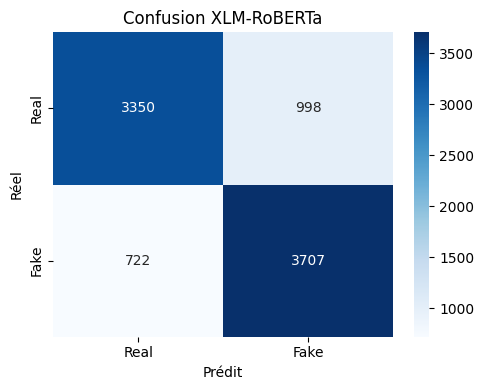

  💾 all_results.pkl

✅ GPU libéré


In [ ]:
# ============================================================
# 9.3 — Fine-tuning + Évaluation + Sauvegarde
# ============================================================

# ── Fine-tuning (skippé si modèle déjà sauvegardé) ─────────
if os.path.isdir(P['xlm_model']):
    print('⏩ Fine-tuning déjà fait — modèle chargé depuis Drive')
else:
    print('🔄 Fine-tuning XLM-RoBERTa...')
    trainer.train()
    xlm_model.save_pretrained(P['xlm_model'])
    xlm_tokenizer.save_pretrained(P['xlm_model'])
    print(f'✅ Modèle sauvegardé → {P["xlm_model"]}')

# ── Évaluation finale — chargée si déjà calculée ───────────
if ckpt_exists(P['xlm_preds']):
    print('⏩ Prédictions XLM déjà calculées — chargement...')
    _xlm = ckpt_load(P['xlm_preds'])
    xlm_preds  = _xlm['preds']
    xlm_labels = _xlm['labels']
    xlm_proba  = _xlm['proba']
else:
    print('🔄 Prédiction sur test set...')
    xlm_out    = trainer.predict(test_ds)
    xlm_preds  = np.argmax(xlm_out.predictions, axis=-1)
    xlm_labels = xlm_out.label_ids
    xlm_proba  = torch.softmax(
        torch.tensor(xlm_out.predictions), dim=-1
    ).numpy()[:, 1]
    ckpt_save(P['xlm_preds'], {
        'preds' : xlm_preds,
        'labels': xlm_labels,
        'proba' : xlm_proba
    })

# ── Métriques ──────────────────────────────────────────────
metrics_xlm = compute_metrics(xlm_labels, xlm_preds, xlm_proba, 'XLM-RoBERTa')
plot_confusion(xlm_labels, xlm_preds, 'Confusion XLM-RoBERTa')

# ── Ajout aux résultats globaux ────────────────────────────
if 'XLM-RoBERTa' not in {r['Model'] for r in all_results}:
    all_results.append(metrics_xlm)
    ckpt_save(P['results'], all_results)

# ── Libérer GPU ────────────────────────────────────────────
del xlm_model, trainer
torch.cuda.empty_cache(); gc.collect()
print('\n✅ GPU libéré')

---
## Étape 10 — Comparaison finale des modèles
> Tableau récapitulatif trié par F1. Conclusion automatique.

In [ ]:
# ── Restaurer les résultats si nécessaire ──────────────────
if not all_results and ckpt_exists(P['results']):
    all_results = ckpt_load(P['results'])

df_results = pd.DataFrame(all_results).sort_values('F1', ascending=False).reset_index(drop=True)

print('\n' + '='*70)
print('COMPARAISON FINALE DES MODÈLES')
print('='*70)
print(df_results.to_string(index=False))
print('='*70)

best_model = df_results.iloc[0]
print(f'\n🏆 Meilleur modèle : {best_model["Model"]}')
print(f'   F1       : {best_model["F1"]:.4f}')
print(f'   Accuracy : {best_model["Accuracy"]:.4f}')


COMPARAISON FINALE DES MODÈLES
       Model  Accuracy  Precision  Recall     F1    AUC
 XLM-RoBERTa    0.8040     0.7879  0.8370 0.8117 0.9072
      BiLSTM    0.7834     0.7180  0.9332 0.8116 0.9065
LR + AraBERT    0.6820     0.6830  0.6794 0.6812 0.7660

🏆 Meilleur modèle : XLM-RoBERTa
   F1       : 0.8117
   Accuracy : 0.8040


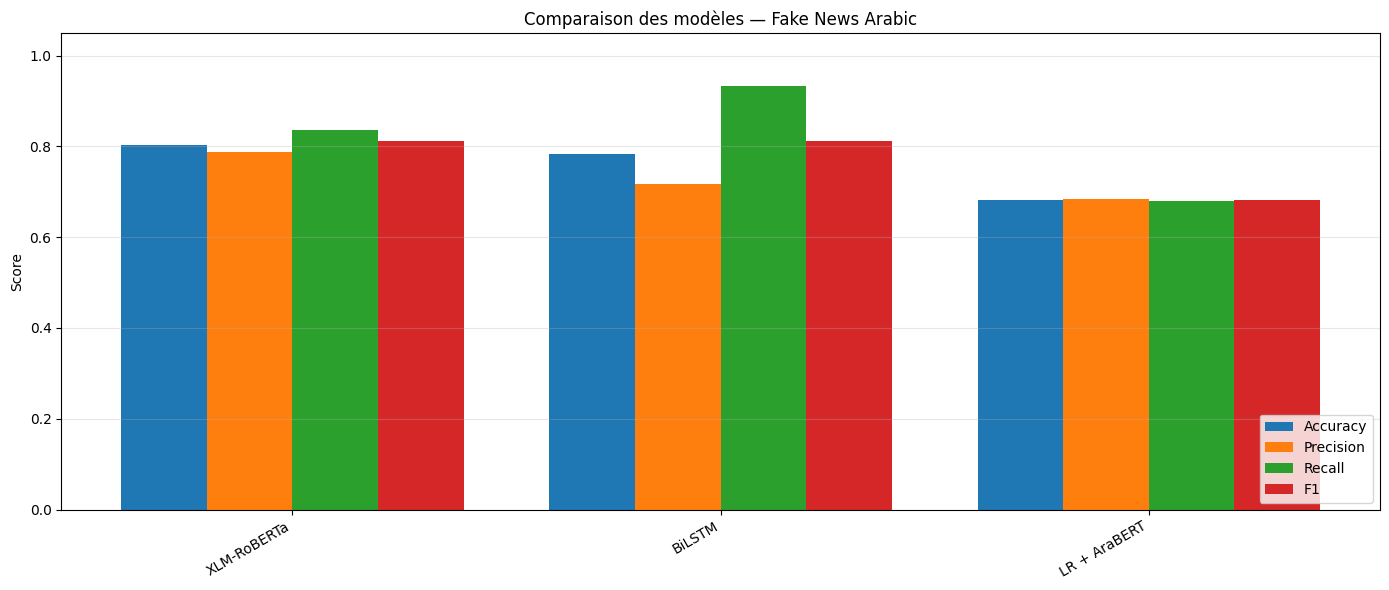

In [ ]:
# ── Visualisation comparaison ──────────────────────────────
metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1']
x = np.arange(len(df_results))
width = 0.2

fig, ax = plt.subplots(figsize=(14, 6))
for i, m in enumerate(metrics_to_plot):
    if m in df_results.columns:
        ax.bar(x + i*width, df_results[m], width, label=m)

ax.set_xticks(x + width * (len(metrics_to_plot)-1)/2)
ax.set_xticklabels(df_results['Model'], rotation=30, ha='right')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('Comparaison des modèles — Fake News Arabic')
ax.legend(loc='lower right')
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

---
## Étape 11 — Inférence / Prédiction
> Fonction finale `predict_fake_news()` utilisant le meilleur modèle entraîné (BiLSTM par défaut).  
> Tous les objets nécessaires (tokenizer, modèle) sont chargés explicitement.

In [ ]:
# ── Chargement explicite pour inférence ───────────────────
print('🔄 Chargement des objets nécessaires pour l\'inférence...')

_infer_tokenizer   = ckpt_load(P['keras_tok'])
_infer_lstm        = tf.keras.models.load_model(P['lstm_model'])
_infer_threshold   = best_threshold if 'best_threshold' in dir() else 0.5
_infer_max_len     = MAX_LEN

print(f'✅ Tokenizer   : {len(_infer_tokenizer.word_index):,} mots')
print(f'✅ LSTM model  : {_infer_lstm.name}')
print(f'✅ Seuil       : {_infer_threshold}')


def predict_fake_news(text: str, threshold: float = _infer_threshold) -> dict:
    """
    Prédit si un texte arabe est fake ou real.

    Args:
        text      : Texte arabe brut
        threshold : Seuil de décision (0.5 par défaut, optimal depuis évaluation)

    Returns:
        dict avec prob_fake, label, cleaned_text
    """
    cleaned  = clean_arabic_text(text)
    if not cleaned:
        print('⚠️  Texte vide après nettoyage')
        return None

    sequence = _infer_tokenizer.texts_to_sequences([cleaned])
    padded   = pad_sequences(
        sequence, maxlen=_infer_max_len,
        padding='post', truncating='post', dtype='int32'
    )
    prob       = float(_infer_lstm.predict(padded, verbose=0)[0][0])
    pred_class = int(prob >= threshold)
    label      = '🔴 FAKE' if pred_class == 1 else '🟢 REAL'

    print(f'Texte nettoyé  : {cleaned[:120]}...')
    print(f'Prob(Fake)     : {prob:.4f}')
    print(f'Seuil          : {threshold}')
    print(f'Prédiction     : {label}')
    return {'prob_fake': prob, 'pred_class': pred_class,
            'label': label, 'cleaned_text': cleaned}


print('\n✅ Fonction predict_fake_news() prête')

🔄 Chargement des objets nécessaires pour l'inférence...
✅ Tokenizer   : 344,940 mots
✅ LSTM model  : bilstm_arabic
✅ Seuil       : 0.5

✅ Fonction predict_fake_news() prête


In [ ]:
# ── Test d'inférence ───────────────────────────────────────
example_real = (
    "رام الله دنيا الوطنأدانت المنظمة العربية للتربية والثقافة والعلوم ألكسو بشدة العدوان الواسع يقترفه الاحتلال الإسرائيلي الشعبالفلسطيني كافة الأرض الفلسطينية المحتلة والقصف الهمجي يستهدف المدنيين الأبرياءو جاء العدوان ردا رفض الشعب الفلسطيني مخططات وممارسات المستوطنين المتطرفين تتبنى الحكومة الإسرائيلية أجندتهم يصرون تهويد مدينة القدس الشرقية عاصمة الدولة الفلسطينية وتشويه هويتها العربية وتهجير أهلها الفلسطينيين وتغيير وضعها القانوني والتاريخي ومقدساتها الدينية المسجد الأقصى المبارك أولى القبلتين وثالث الحرمين وذلك تحد صارخ للمجتمع الدولي وقرارات الشرعية الدوليةوفي الإطار تذكر ألكسو مئات القرارات الدولية بقرار المجلس التنفيذي لليونسكو 26 2016 يؤكد القدس مدينة محتلة تذكر بقرار مجلس الأمن رقم 2334 بتاريخ 23 ديسمبر2016 يؤكد جديد انطباق اتفاقية جنيف المتعلقة بحماية الأشخاص المدنيين وقت الحربالمؤرخة 12 1949 الأراضي الفلسطينية القدس الشرقية والأراضي العربية الأخرى المحتلة 1967 الأنشطة الاستيطانية الإسرائيلية الأرض الفلسطينية المحتلة قانونية بموجب القانون الدوليوتشكل عقبة رئيسية تحقيق السلام أساس حل الدولتينو أدان التدابير الأخرى الرامية تغيير التكوين الديمغرافي وطابع ووضع الأرض الفلسطينية المحتلة العام 1967 القدس الشرقية يشمل جملة أمور بناء وتوسيع المستوطنات ونقل المستوطنين الإسرائيليين ومصادرة وضم الأرض بالأمر الواقع وهدم المنازل والنقل القسري للمدنيين الفلسطينيين انتهاك للقانون الإنساني الدولي والقرارات الصلةوتذكر ألكسو بأن اتفاقيات جنيف الاتفاقية الرابعة تسري الأراضي الفلسطينية المحتلة تنص الأطراف الموقعة تتعهد بأن تحترم الاتفاقيات تكفل احترامها الأحوال ولذلك واجب الأطراف الاتفاقيات وخاصة القوى العظمى بحكم مسؤولياتها الدولية والتزاماتها القانونية والسياسية والأخلاقية مدافع أحكام القانون الدولي الإنساني الواضحة تنص المحتل يكتسب السيادة الأرض المحتلة قيام دولة الاحتلال بنقل سكانها المدنيين الأراضي تحتلها ترحيل نقل سكان الأراضي المحتلة داخل نطاق الأراضي خارجها وكذلك شن الهجمات الآثار التاريخية وأماكن العبادة يعتبر انتهاكات جسيمة بمثابة جرائم حربو دعت ألكسو المنظمات الإقليمية والدولية مقدمتها منظمة اليونسكو للتحرك العاجل والقوي لحمل دولة الاحتلال وضع حد لانتهاكاتها المتواصلة للقرارات الدولية")
example_fake = (
    "تم اكتشاف علاج سحري يقضي على السرطان في يوم واحد فقط بدون آثار جانبية "
    "والحكومة تخفي هذا الاكتشاف عن الشعب"
)

print('═'*60)
print('Exemple 1 (probablement REAL)')
print('═'*60)
predict_fake_news(example_real)

print('\n' + '═'*60)
print('Exemple 2 (probablement FAKE)')
print('═'*60)
predict_fake_news(example_fake)

════════════════════════════════════════════════════════════
Exemple 1 (probablement REAL)
════════════════════════════════════════════════════════════
Texte nettoyé  : رام الله دنيا الوطنأدانت المنظمة العربية للتربية والثقافة والعلوم ألكسو بشدة العدوان الواسع يقترفه الاحتلال الإسرائيلي ا...
Prob(Fake)     : 0.4817
Seuil          : 0.5
Prédiction     : 🟢 REAL

════════════════════════════════════════════════════════════
Exemple 2 (probablement FAKE)
════════════════════════════════════════════════════════════
Texte nettoyé  : تم اكتشاف علاج سحري يقضي على السرطان في يوم واحد فقط بدون آثار جانبية والحكومة تخفي هذا الاكتشاف عن الشعب...
Prob(Fake)     : 0.6116
Seuil          : 0.5
Prédiction     : 🔴 FAKE


{'prob_fake': 0.6115714311599731,
 'pred_class': 1,
 'label': '🔴 FAKE',
 'cleaned_text': 'تم اكتشاف علاج سحري يقضي على السرطان في يوم واحد فقط بدون آثار جانبية والحكومة تخفي هذا الاكتشاف عن الشعب'}